# Logistic Regression

This notebook uses the same ISLP `Default` problem as Lecture 07. We implement
logistic regression, Newton's method, and threshold evaluation from scratch
before comparing with scikit-learn.

In [1]:
# Colab opens this notebook on its own, so fetch the data files that sit
# beside it in the course repository. Running locally, this does nothing.
from pathlib import Path as _Path
import urllib.request as _req
_RAW = 'https://raw.githubusercontent.com/ZhuoranYang/sds265-fall26/main/demos/08-logistic-classification/'
for _name in ['Default.csv']:
    if not _Path(_name).exists():
        _req.urlretrieve(_RAW + _name, _name)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 26508
rng = np.random.default_rng(SEED)
default = pd.read_csv('Default.csv')
y = (default['default'] == 'Yes').to_numpy(int)
X_raw = default[['balance', 'income']].to_numpy(float)
print(f'rows={len(y):,}; defaults={y.sum():,}; prevalence={y.mean():.4%}')
assert len(y) == 10_000 and y.sum() == 333

rows=10,000; defaults=333; prevalence=3.3300%


## A stratified train/test split

In [2]:
train_parts, test_parts = [], []
for k in (0, 1):
    idx = rng.permutation(np.flatnonzero(y == k))
    cut = int(.70 * len(idx))
    train_parts.append(idx[:cut])
    test_parts.append(idx[cut:])
train = rng.permutation(np.concatenate(train_parts))
test = rng.permutation(np.concatenate(test_parts))

mu, sd = X_raw[train].mean(0), X_raw[train].std(0)
Xtr_features = (X_raw[train] - mu) / sd
Xte_features = (X_raw[test] - mu) / sd
Xtr = np.column_stack([np.ones(len(train)), Xtr_features])
Xte = np.column_stack([np.ones(len(test)), Xte_features])
ytr, yte = y[train], y[test]
len(train), len(test), ytr.sum(), yte.sum()

(6999, 3001, np.int64(233), np.int64(100))

## Logistic regression from scratch

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -40, 40)))

def cross_entropy(X, y, w):
    z = X @ w
    return np.mean(np.logaddexp(0, z) - y * z)

def gradient_hessian(X, y, w):
    p = sigmoid(X @ w)
    gradient = X.T @ (p - y) / len(y)
    weights = p * (1 - p)
    hessian = X.T @ (weights[:, None] * X) / len(y)
    return gradient, hessian

def fit_newton(X, y, iterations=30):
    w = np.zeros(X.shape[1])
    history = []
    for iteration in range(iterations):
        gradient, hessian = gradient_hessian(X, y, w)
        history.append((iteration, cross_entropy(X, y, w), np.linalg.norm(gradient)))
        step = np.linalg.solve(hessian + 1e-8 * np.eye(X.shape[1]), gradient)
        w -= step
        if np.linalg.norm(step) < 1e-9:
            break
    return w, pd.DataFrame(history, columns=['iteration', 'loss', 'gradient_norm'])

w_hat, history = fit_newton(Xtr, ytr)
print('coefficients [intercept, balance, income]:', w_hat)
history

coefficients [intercept, balance, income]: [-5.94239453  2.60361563  0.22599071]


,iteration,loss,gradient_norm
0,0,0.693147,4.708863e-01
1,1,0.193932,1.083169e-01
2,2,0.122770,3.903882e-02
3,3,0.095016,1.506899e-02
4,4,0.084238,5.475853e-03
5,5,0.081488,1.530426e-03
6,6,0.081218,1.873717e-04
7,7,0.081214,3.000698e-06
8,8,0.081214,7.072394e-10
9,9,0.081214,1.895902e-15


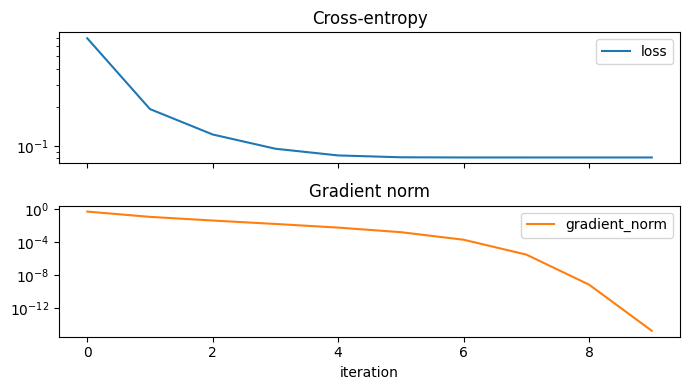

In [4]:
history.plot(x='iteration', y=['loss', 'gradient_norm'], subplots=True,
             figsize=(7, 4), logy=True, title=['Cross-entropy', 'Gradient norm'])
plt.tight_layout();

## Verify the gradient numerically

In [5]:
gradient, hessian = gradient_hessian(Xtr, ytr, w_hat)
eps = 1e-5
finite_difference = np.empty_like(w_hat)
for j in range(len(w_hat)):
    direction = np.zeros_like(w_hat); direction[j] = eps
    finite_difference[j] = (cross_entropy(Xtr, ytr, w_hat + direction)
                            - cross_entropy(Xtr, ytr, w_hat - direction)) / (2 * eps)
print('analytic gradient:', gradient)
print('finite difference:', finite_difference)
print('Hessian eigenvalues:', np.linalg.eigvalsh(hessian))
assert np.allclose(gradient, finite_difference, atol=1e-7)
assert np.linalg.eigvalsh(hessian).min() >= -1e-10

analytic gradient: [-4.94714682e-18 -1.62734410e-17  4.34275927e-18]
finite difference: [0.0000000e+00 0.0000000e+00 6.9388939e-13]
Hessian eigenvalues: [0.0024112  0.02399953 0.08525031]


## Thresholds and unequal costs

In [6]:
p_test = sigmoid(Xte @ w_hat)

def confusion(y, p, threshold):
    pred = p >= threshold
    return {
        'threshold': threshold,
        'TN': np.sum(~pred & (y == 0)),
        'FP': np.sum(pred & (y == 0)),
        'FN': np.sum(~pred & (y == 1)),
        'TP': np.sum(pred & (y == 1)),
    }

table = pd.DataFrame([confusion(yte, p_test, t) for t in (.50, .20, .05)])
table['precision'] = table.TP / (table.TP + table.FP)
table['recall'] = table.TP / (table.TP + table.FN)
table

,threshold,TN,FP,FN,TP,precision,recall
0,0.50,2896,5,64,36,0.878049,0.36
1,0.20,2821,80,38,62,0.436620,0.62
2,0.05,2606,295,10,90,0.233766,0.90


## Ranking and probability metrics

In [7]:
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss, brier_score_loss

metrics = {
    'ROC AUC': roc_auc_score(yte, p_test),
    'average precision': average_precision_score(yte, p_test),
    'log loss': log_loss(yte, p_test),
    'Brier score': brier_score_loss(yte, p_test),
}
metrics

{'ROC AUC': 0.9575456739055498,
 'average precision': 0.5906445877514361,
 'log loss': 0.07394428416144158,
 'Brier score': 0.019947274855934942}

In [8]:
# Preserve ranking but distort confidence.
logit = np.log(np.clip(p_test, 1e-8, 1-1e-8) / np.clip(1-p_test, 1e-8, 1))
p_distorted = sigmoid(1.8 * logit)
pd.DataFrame({
    'original': [roc_auc_score(yte, p_test), log_loss(yte, p_test), brier_score_loss(yte, p_test)],
    'distorted': [roc_auc_score(yte, p_distorted), log_loss(yte, p_distorted), brier_score_loss(yte, p_distorted)],
}, index=['ROC AUC', 'log loss', 'Brier score'])

,original,distorted
ROC AUC,0.957546,0.957546
log loss,0.073944,0.088538
Brier score,0.019947,0.020252


## Library comparison

In [9]:
from sklearn.linear_model import LogisticRegression

library = LogisticRegression(penalty=None, solver='lbfgs', max_iter=10000, tol=1e-12)
library.fit(Xtr_features, ytr)
library_p = library.predict_proba(Xte_features)[:, 1]
print('scikit-learn coefficients:', np.r_[library.intercept_, library.coef_.ravel()])
print('maximum probability difference:', np.max(np.abs(library_p - p_test)))
assert np.max(np.abs(library_p - p_test)) < 1e-5

scikit-learn coefficients: [-5.94239455  2.60361564  0.22599071]
maximum probability difference: 7.640985622003882e-10


## Part 2 --- every figure in the slides

These cells are the code that produced the figures in the deck, with each file write replaced by an inline plot.

In [10]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The course palette and figure sizes, copied from slides/figures/sds265_style.py
BLUE, BLUE_BRIGHT, RED, GREEN = '#00356B', '#286DC0', '#7A3E47', '#5B7864'
INK, MUTED, RULE, BLUE_PALE = '#202A35', '#66727E', '#D8E0E8', '#F2F6FA'
BLUE_FILL, RED_FILL, GREEN_FILL = '#7B8FA3', '#A3838A', '#8FA394'
CYCLE = [BLUE, RED, GREEN, BLUE_BRIGHT, MUTED]
TEXTWIDTH, TEXTHEIGHT = 5.63, 3.09
FULL, FULL_TALL, FULL_SHORT = (TEXTWIDTH, 2.0), (TEXTWIDTH, 2.35), (TEXTWIDTH, 1.7)
HALF, HALF_TALL = (2.70, 2.05), (2.70, 2.45)

def use_course_style():
    mpl.rcParams.update({'figure.dpi': 130, 'font.size': 9, 'axes.titlecolor': BLUE,
                         'axes.edgecolor': MUTED, 'axes.linewidth': .7,
                         'axes.spines.top': False, 'axes.spines.right': False,
                         'xtick.color': MUTED, 'ytick.color': MUTED,
                         'legend.frameon': False, 'lines.linewidth': 1.8,
                         'axes.prop_cycle': mpl.cycler(color=CYCLE)})

def save(fig, *paths):     # the deck writes files; the notebook shows the plot
    plt.show()
    return Path(paths[0]) if paths else Path('figure.pdf')

use_course_style()
# The figure scripts locate the data through OUT.parents[2]; point OUT at the
# directory the deck uses because figure names are derived from it.
COURSE = Path.cwd().parents[1]
OUT = COURSE / 'slides' / 'figures' / '08-logistic-classification'
NOTES = COURSE / 'lectures' / 'figures'

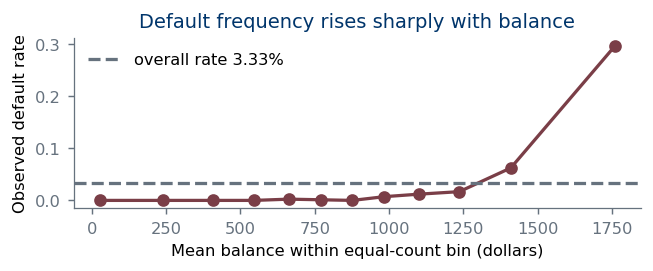

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/08-logistic-classification/default-rate-by-balance.pdf')

In [11]:
from __future__ import annotations


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)





SEED = 26508
rng = np.random.default_rng(SEED)


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -40, 40)))


def loss(X, y, w):
    z = X @ w
    return np.mean(np.logaddexp(0.0, z) - y * z)


def fit_logistic_newton(X, y, iterations=30):
    w = np.zeros(X.shape[1])
    history = [w.copy()]
    for _ in range(iterations):
        p = sigmoid(X @ w)
        gradient = X.T @ (p - y) / len(y)
        weights = p * (1 - p)
        hessian = X.T @ (weights[:, None] * X) / len(y)
        step = np.linalg.solve(hessian + 1e-8 * np.eye(X.shape[1]), gradient)
        w -= step
        history.append(w.copy())
        if np.linalg.norm(step) < 1e-9:
            break
    return w, np.asarray(history)


default = pd.read_csv('Default.csv')
y = (default["default"] == "Yes").to_numpy(int)
raw = default[["balance", "income"]].to_numpy(float)

# Reproducible stratified split.
train_parts, test_parts = [], []
for k in (0, 1):
    idx = rng.permutation(np.flatnonzero(y == k))
    cut = int(0.70 * len(idx))
    train_parts.append(idx[:cut])
    test_parts.append(idx[cut:])
train = rng.permutation(np.concatenate(train_parts))
test = rng.permutation(np.concatenate(test_parts))

mu, sd = raw[train].mean(0), raw[train].std(0)
X_train_features = (raw[train] - mu) / sd
X_test_features = (raw[test] - mu) / sd
X_train = np.column_stack([np.ones(len(train)), X_train_features])
X_test = np.column_stack([np.ones(len(test)), X_test_features])
y_train, y_test = y[train], y[test]
w_hat, history = fit_logistic_newton(X_train, y_train)
p_test = sigmoid(X_test @ w_hat)


# Empirical relationship between balance and default rate.
bins = pd.qcut(default["balance"], 12, duplicates="drop")
grouped = default.assign(y=y).groupby(bins, observed=True).agg(
    balance=("balance", "mean"), rate=("y", "mean"), count=("y", "size")
)
fig, ax = plt.subplots(figsize=FULL_SHORT)
ax.plot(grouped["balance"], grouped["rate"], "o-", color=RED)
ax.axhline(y.mean(), color=MUTED, linestyle="--", label=f"overall rate {y.mean():.2%}")
ax.set(xlabel="Mean balance within equal-count bin (dollars)", ylabel="Observed default rate", title="Default frequency rises sharply with balance")
ax.legend()
save(fig, OUT / "default-rate-by-balance.pdf", OUT / "default-rate-by-balance.svg")

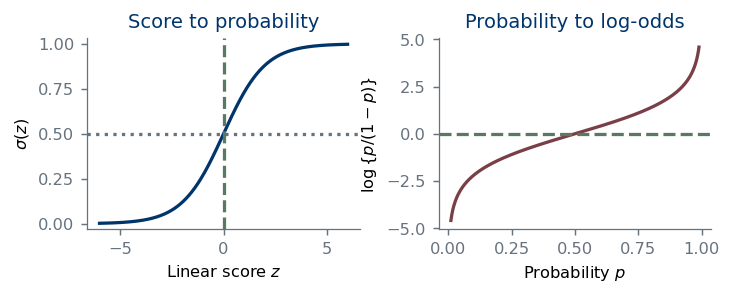

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/08-logistic-classification/sigmoid-logodds.pdf')

In [12]:
# Score, sigmoid, and log-odds.
z = np.linspace(-6, 6, 500)
p = sigmoid(z)
fig, axes = plt.subplots(1, 2, figsize=FULL_TALL)
axes[0].plot(z, p, color=BLUE)
axes[0].axhline(0.5, color=MUTED, linestyle=":")
axes[0].axvline(0, color=GREEN, linestyle="--")
axes[0].set(xlabel="Linear score $z$", ylabel=r"$\sigma(z)$", title="Score to probability", ylim=(-0.03, 1.03))
prob = np.linspace(0.01, 0.99, 500)
axes[1].plot(prob, np.log(prob / (1 - prob)), color=RED)
axes[1].axhline(0, color=GREEN, linestyle="--")
axes[1].set(xlabel="Probability $p$", ylabel=r"$\log\{p/(1-p)\}$", title="Probability to log-odds")
fig.tight_layout(w_pad=1.0)
save(fig, OUT / "sigmoid-logodds.pdf", OUT / "sigmoid-logodds.svg")

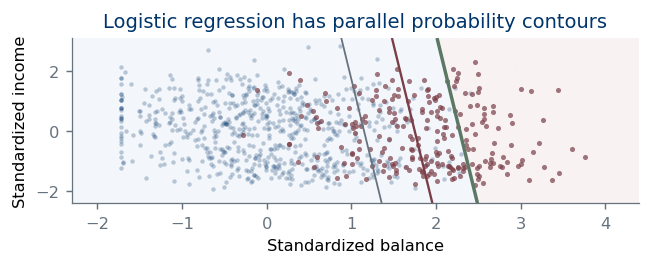

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/08-logistic-classification/probability-boundary.pdf')

In [13]:
# Fitted probability field on the real Default data.
gx, gy = np.meshgrid(np.linspace(-2.3, 4.4, 280), np.linspace(-2.4, 3.1, 260))
grid = np.column_stack([np.ones(gx.size), gx.ravel(), gy.ravel()])
surface = sigmoid(grid @ w_hat).reshape(gx.shape)
fig, ax = plt.subplots(figsize=(FULL_SHORT[0], 1.65))
ax.contourf(gx, gy, surface, levels=np.linspace(0, 1, 11), colors=[BLUE_PALE] * 5 + ["#F8F1F2"] * 5, alpha=0.9)
ax.contour(gx, gy, surface, levels=[0.05, 0.20, 0.50], colors=[MUTED, RED, GREEN], linewidths=[1.0, 1.3, 1.9])
neg = rng.choice(np.flatnonzero(y_train == 0), 650, replace=False)
pos = np.flatnonzero(y_train == 1)
ax.scatter(X_train_features[neg, 0], X_train_features[neg, 1], s=6, color=BLUE, alpha=0.25, linewidths=0)
ax.scatter(X_train_features[pos, 0], X_train_features[pos, 1], s=8, color=RED, alpha=0.7, linewidths=0)
ax.set(xlabel="Standardized balance", ylabel="Standardized income", title="Logistic regression has parallel probability contours")
save(fig, OUT / "probability-boundary.pdf", OUT / "probability-boundary.svg")

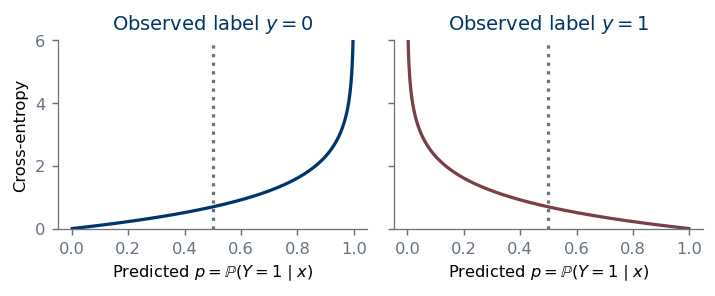

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/08-logistic-classification/cross-entropy.pdf')

In [14]:
# Binary cross-entropy.
prob = np.linspace(0.002, 0.998, 600)
fig, axes = plt.subplots(1, 2, figsize=FULL_TALL, sharey=True)
axes[0].plot(prob, -np.log(1 - prob), color=BLUE)
axes[0].set(title="Observed label $y=0$", xlabel=r"Predicted $p=\mathbb{P}(Y=1\mid x)$", ylabel="Cross-entropy")
axes[1].plot(prob, -np.log(prob), color=RED)
axes[1].set(title="Observed label $y=1$", xlabel=r"Predicted $p=\mathbb{P}(Y=1\mid x)$")
for ax in axes:
    ax.set(ylim=(0, 6))
    ax.axvline(0.5, color=MUTED, linestyle=":")
fig.tight_layout(w_pad=0.8)
save(fig, OUT / "cross-entropy.pdf", OUT / "cross-entropy.svg")

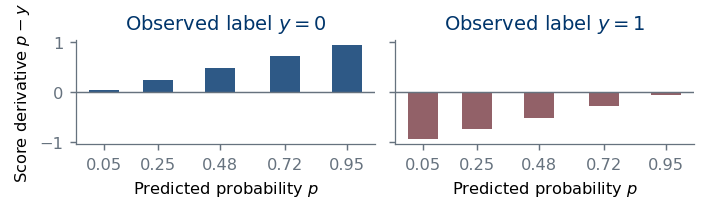

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/08-logistic-classification/gradient-residuals.pdf')

In [15]:
# Gradient contributions p-y.
probs = np.array([0.05, 0.25, 0.48, 0.72, 0.95])
fig, axes = plt.subplots(1, 2, figsize=FULL_SHORT, sharey=True)
for ax, label, color in [(axes[0], 0, BLUE), (axes[1], 1, RED)]:
    residual = probs - label
    ax.axhline(0, color=MUTED, linewidth=0.8)
    ax.bar(probs, residual, width=0.11, color=color, alpha=0.82)
    ax.set(title=f"Observed label $y={label}$", xlabel="Predicted probability $p$", xticks=probs, ylim=(-1.05, 1.05))
axes[0].set_ylabel("Score derivative $p-y$")
fig.tight_layout(w_pad=0.8)
save(fig, OUT / "gradient-residuals.pdf", OUT / "gradient-residuals.svg")

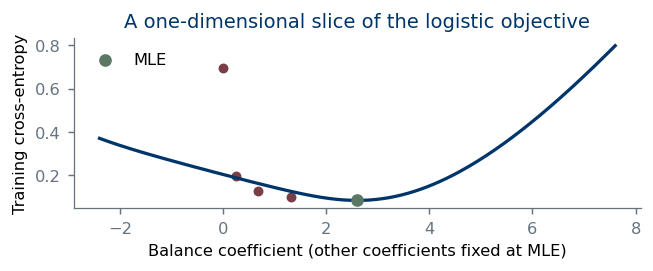

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/08-logistic-classification/convex-loss-slice.pdf')

In [16]:
# Convex loss along the balance coefficient through the optimum.
offsets = np.linspace(-5.0, 5.0, 240)
slice_loss = []
for offset in offsets:
    trial = w_hat.copy()
    trial[1] += offset
    slice_loss.append(loss(X_train, y_train, trial))
fig, ax = plt.subplots(figsize=FULL_SHORT)
ax.plot(w_hat[1] + offsets, slice_loss, color=BLUE)
ax.scatter([w_hat[1]], [loss(X_train, y_train, w_hat)], color=GREEN, zorder=3, label="MLE")
for j in range(min(4, len(history))):
    ax.scatter(history[j, 1], loss(X_train, y_train, history[j]), color=RED, s=20)
ax.set(xlabel="Balance coefficient (other coefficients fixed at MLE)", ylabel="Training cross-entropy", title="A one-dimensional slice of the logistic objective")
ax.legend()
save(fig, OUT / "convex-loss-slice.pdf", OUT / "convex-loss-slice.svg")

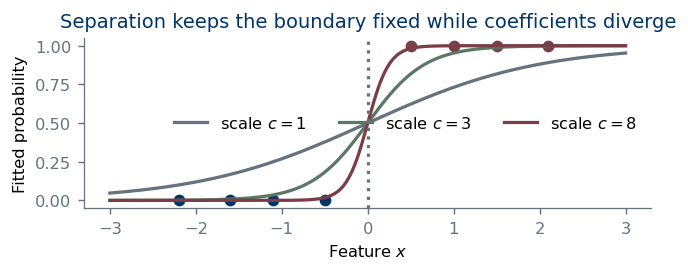

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/08-logistic-classification/complete-separation.pdf')

In [17]:
# Complete separation: fixed boundary, diverging scale.
x_sep = np.array([-2.2, -1.6, -1.1, -0.5, 0.5, 1.0, 1.5, 2.1])
y_sep = (x_sep > 0).astype(int)
grid_sep = np.linspace(-3, 3, 500)
fig, ax = plt.subplots(figsize=FULL_SHORT)
ax.scatter(x_sep[y_sep == 0], y_sep[y_sep == 0], color=BLUE, s=30)
ax.scatter(x_sep[y_sep == 1], y_sep[y_sep == 1], color=RED, s=30)
for scale, color in [(1, MUTED), (3, GREEN), (8, RED)]:
    ax.plot(grid_sep, sigmoid(scale * grid_sep), color=color, label=f"scale $c={scale}$")
ax.axvline(0, color=MUTED, linestyle=":")
ax.set(xlabel="Feature $x$", ylabel="Fitted probability", ylim=(-0.05, 1.05), title="Separation keeps the boundary fixed while coefficients diverge")
ax.legend(ncol=3)
save(fig, OUT / "complete-separation.pdf", OUT / "complete-separation.svg")

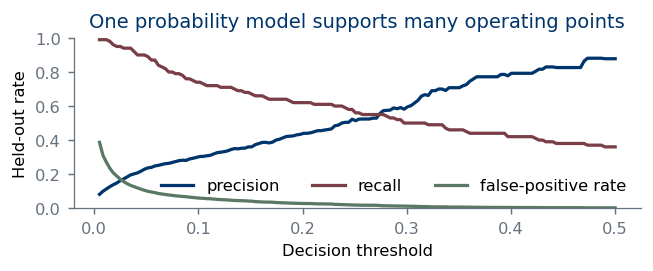

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/08-logistic-classification/threshold-sweep.pdf')

In [18]:
# Threshold metrics from held-out Default probabilities.
thresholds = np.linspace(0.005, 0.50, 150)
precision, recall, fpr = [], [], []
for threshold in thresholds:
    pred = p_test >= threshold
    tp = np.sum(pred & (y_test == 1))
    fp = np.sum(pred & (y_test == 0))
    fn = np.sum(~pred & (y_test == 1))
    tn = np.sum(~pred & (y_test == 0))
    precision.append(tp / max(tp + fp, 1))
    recall.append(tp / max(tp + fn, 1))
    fpr.append(fp / max(fp + tn, 1))
fig, ax = plt.subplots(figsize=FULL_SHORT)
ax.plot(thresholds, precision, color=BLUE, label="precision")
ax.plot(thresholds, recall, color=RED, label="recall")
ax.plot(thresholds, fpr, color=GREEN, label="false-positive rate")
ax.set(xlabel="Decision threshold", ylabel="Held-out rate", ylim=(0, 1), title="One probability model supports many operating points")
ax.legend(ncol=3)
save(fig, OUT / "threshold-sweep.pdf", OUT / "threshold-sweep.svg")

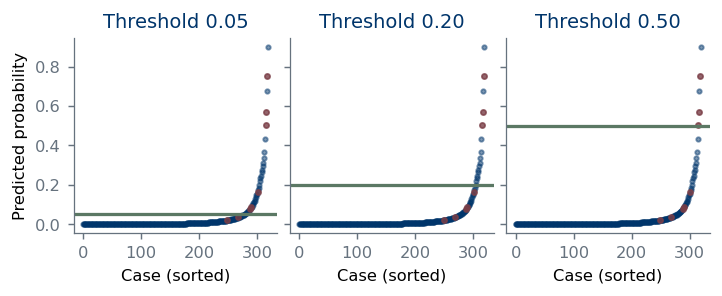

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/08-logistic-classification/demo-thresholds.pdf')

In [19]:
# Static fallback for threshold exploration on the same held-out cases.
order = np.argsort(p_test)
choose = order[np.linspace(0, len(order) - 1, 320, dtype=int)]
p_demo, y_demo = p_test[choose], y_test[choose]
case = np.arange(len(choose))
fig, axes = plt.subplots(1, 3, figsize=FULL_TALL, sharex=True, sharey=True)
for ax, threshold in zip(axes, [0.05, 0.20, 0.50]):
    ax.scatter(case[y_demo == 0], p_demo[y_demo == 0], s=6, color=BLUE, alpha=0.5)
    ax.scatter(case[y_demo == 1], p_demo[y_demo == 1], s=8, color=RED, alpha=0.8)
    ax.axhline(threshold, color=GREEN)
    ax.set(title=f"Threshold {threshold:.2f}", xlabel="Case (sorted)")
axes[0].set_ylabel("Predicted probability")
fig.tight_layout(w_pad=0.4)
save(fig, OUT / "demo-thresholds.pdf", OUT / "demo-thresholds.svg")

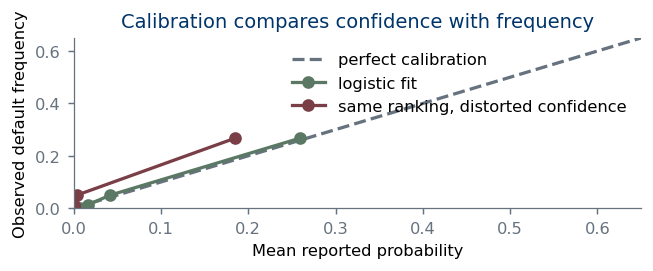

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/08-logistic-classification/calibration-curves.pdf')

In [20]:
# Real reliability curve plus deliberately distorted probabilities.
def reliability(probabilities, outcomes, groups=10):
    frame = pd.DataFrame({"p": probabilities, "y": outcomes})
    frame["bin"] = pd.qcut(frame["p"], groups, duplicates="drop")
    summary = frame.groupby("bin", observed=True).agg(p=("p", "mean"), rate=("y", "mean"))
    return summary["p"].to_numpy(), summary["rate"].to_numpy()


reported, observed = reliability(p_test, y_test)
distorted = sigmoid(1.8 * np.log(np.clip(p_test, 1e-6, 1 - 1e-6) / np.clip(1 - p_test, 1e-6, 1)))
reported_bad, observed_bad = reliability(distorted, y_test)
fig, ax = plt.subplots(figsize=FULL_SHORT)
ax.plot([0, 1], [0, 1], color=MUTED, linestyle="--", label="perfect calibration")
ax.plot(reported, observed, "o-", color=GREEN, label="logistic fit")
ax.plot(reported_bad, observed_bad, "o-", color=RED, label="same ranking, distorted confidence")
ax.set(xlabel="Mean reported probability", ylabel="Observed default frequency", xlim=(0, 0.65), ylim=(0, 0.65), title="Calibration compares confidence with frequency")
ax.legend()
save(fig, OUT / "calibration-curves.pdf", OUT / "calibration-curves.svg")

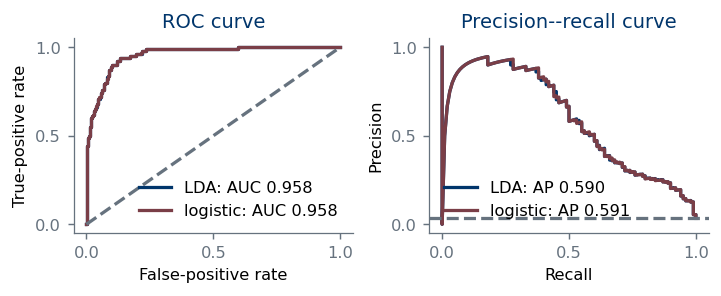

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/08-logistic-classification/lda-logistic-comparison.pdf')

In [21]:
# LDA and logistic regression on exactly the same split.
means = np.array([X_train_features[y_train == k].mean(0) for k in (0, 1)])
covs = [np.cov(X_train_features[y_train == k].T) for k in (0, 1)]
pooled = sum((np.sum(y_train == k) - 1) * covs[k] for k in (0, 1)) / (len(y_train) - 2)
inverse = np.linalg.inv(pooled)
priors = np.array([(y_train == k).mean() for k in (0, 1)])
scores = []
for k in (0, 1):
    scores.append(X_test_features @ inverse @ means[k] - 0.5 * means[k] @ inverse @ means[k] + np.log(priors[k]))
scores = np.column_stack(scores)
p_lda = sigmoid(scores[:, 1] - scores[:, 0])

fig, axes = plt.subplots(1, 2, figsize=FULL_TALL)
for probability, label, color in [(p_lda, "LDA", BLUE), (p_test, "logistic", RED)]:
    fpr_curve, tpr_curve, _ = roc_curve(y_test, probability)
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, probability)
    axes[0].plot(fpr_curve, tpr_curve, color=color, label=f"{label}: AUC {roc_auc_score(y_test, probability):.3f}")
    axes[1].plot(rec_curve, prec_curve, color=color, label=f"{label}: AP {average_precision_score(y_test, probability):.3f}")
axes[0].plot([0, 1], [0, 1], color=MUTED, linestyle="--")
axes[0].set(xlabel="False-positive rate", ylabel="True-positive rate", title="ROC curve")
axes[1].axhline(y_test.mean(), color=MUTED, linestyle="--")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision--recall curve")
for ax in axes:
    ax.set_xticks([0, 0.5, 1.0])
    ax.set_yticks([0, 0.5, 1.0])
    ax.legend()
fig.tight_layout(w_pad=0.9)
save(fig, OUT / "lda-logistic-comparison.pdf", OUT / "lda-logistic-comparison.svg")

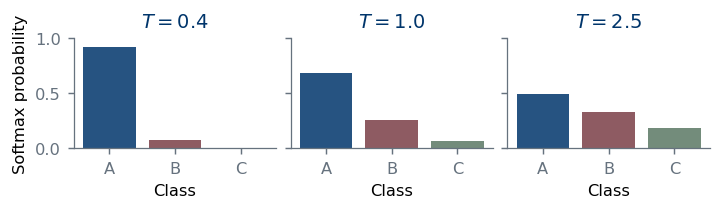

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/08-logistic-classification/softmax-temperature.pdf')

In [22]:
# Softmax temperature on fixed logits.
logits = np.array([2.2, 1.2, -0.2])
temperatures = [0.4, 1.0, 2.5]
fig, axes = plt.subplots(1, 3, figsize=FULL_SHORT, sharey=True)
for ax, temperature in zip(axes, temperatures):
    exponentials = np.exp((logits - logits.max()) / temperature)
    probabilities = exponentials / exponentials.sum()
    ax.bar(["A", "B", "C"], probabilities, color=[BLUE, RED, GREEN], alpha=0.85)
    ax.set(title=f"$T={temperature}$", ylim=(0, 1), xlabel="Class")
axes[0].set_ylabel("Softmax probability")
fig.tight_layout(w_pad=0.5)
save(fig, OUT / "softmax-temperature.pdf", OUT / "softmax-temperature.svg")

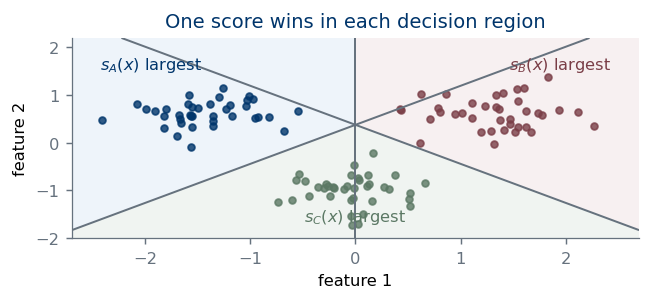

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/08-logistic-classification/multiclass-regions.pdf')

In [23]:
# Three-class regions: one affine score per class, followed by argmax.
gx3, gy3 = np.meshgrid(np.linspace(-2.7, 2.7, 360), np.linspace(-2.0, 2.2, 300))
xy3 = np.column_stack([gx3.ravel(), gy3.ravel()])
centers3 = np.array([[-1.35, 0.65], [1.35, 0.65], [0.0, -1.0]])
scores3 = xy3 @ centers3.T - 0.5 * np.sum(centers3**2, axis=1)
regions3 = np.argmax(scores3, axis=1).reshape(gx3.shape)
fig, ax = plt.subplots(figsize=FULL)
from matplotlib.colors import ListedColormap

ax.contourf(
    gx3,
    gy3,
    regions3,
    levels=[-0.5, 0.5, 1.5, 2.5],
    cmap=ListedColormap(["#EEF4FA", "#F7F0F1", "#F0F4F1"]),
)
palette3 = [BLUE, RED, GREEN]
labels3 = ["class A", "class B", "class C"]
for center, color, label in zip(centers3, palette3, labels3):
    points = rng.normal(loc=center, scale=[0.38, 0.30], size=(38, 2))
    ax.scatter(points[:, 0], points[:, 1], s=14, color=color, alpha=0.8, label=label)
ax.contour(gx3, gy3, scores3[:, 0].reshape(gx3.shape) - scores3[:, 1].reshape(gx3.shape), levels=[0], colors=[MUTED], linewidths=1.1)
ax.contour(gx3, gy3, scores3[:, 0].reshape(gx3.shape) - scores3[:, 2].reshape(gx3.shape), levels=[0], colors=[MUTED], linewidths=1.1)
ax.contour(gx3, gy3, scores3[:, 1].reshape(gx3.shape) - scores3[:, 2].reshape(gx3.shape), levels=[0], colors=[MUTED], linewidths=1.1)
ax.text(-1.95, 1.55, r"$s_A(x)$ largest", color=BLUE, ha="center")
ax.text(1.95, 1.55, r"$s_B(x)$ largest", color=RED, ha="center")
ax.text(0.0, -1.65, r"$s_C(x)$ largest", color=GREEN, ha="center")
ax.set(xlabel="feature 1", ylabel="feature 2", xlim=(-2.7, 2.7), ylim=(-2.0, 2.2), title="One score wins in each decision region")
save(fig, OUT / "multiclass-regions.pdf", OUT / "multiclass-regions.svg")

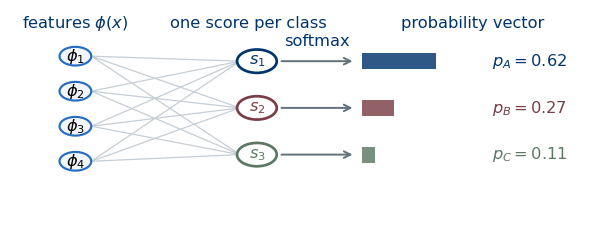

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/08-logistic-classification/softmax-linear-layer.pdf')

In [24]:
# Softmax regression as a feature-to-logit-to-probability computation.
fig, ax = plt.subplots(figsize=FULL)
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis("off")
feature_y = [4.7, 3.65, 2.6, 1.55]
logit_y = [4.55, 3.15, 1.75]
colors = [BLUE, RED, GREEN]
for j, yj in enumerate(feature_y, start=1):
    circle = plt.Circle((1.1, yj), 0.28, facecolor="#F2F6FA", edgecolor=BLUE_BRIGHT, linewidth=1.2)
    ax.add_patch(circle)
    ax.text(1.1, yj, rf"$\phi_{j}$", ha="center", va="center")
for yj in feature_y:
    for yk in logit_y:
        ax.plot([1.38, 4.0], [yj, yk], color="#C6CED6", linewidth=0.7, zorder=0)
for k, (yk, color) in enumerate(zip(logit_y, colors), start=1):
    circle = plt.Circle((4.3, yk), 0.35, facecolor="white", edgecolor=color, linewidth=1.5)
    ax.add_patch(circle)
    ax.text(4.3, yk, rf"$s_{k}$", ha="center", va="center", color=color)
    ax.annotate("", xy=(6.05, yk), xytext=(4.67, yk), arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.1))
ax.text(5.35, 5.00, "softmax", ha="center", color=BLUE)
probabilities = [0.62, 0.27, 0.11]
names = ["A", "B", "C"]
for yk, color, probability, name in zip(logit_y, colors, probabilities, names):
    ax.barh(yk, probability * 2.1, left=6.15, height=0.48, color=color, alpha=0.82)
    ax.text(8.45, yk, rf"$p_{name}={probability:.2f}$", va="center", color=color)
ax.text(1.1, 5.55, r"features $\phi(x)$", ha="center", color=BLUE)
ax.text(4.15, 5.55, "one score per class", ha="center", color=BLUE)
ax.text(8.1, 5.55, "probability vector", ha="center", color=BLUE)
save(fig, OUT / "softmax-linear-layer.pdf", OUT / "softmax-linear-layer.svg")

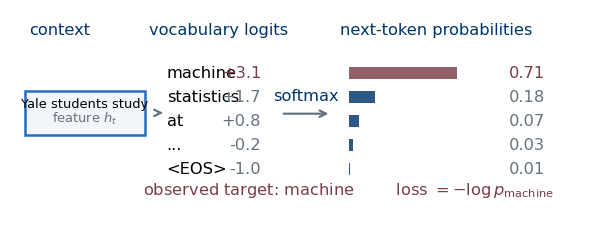

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/08-logistic-classification/token-softmax-bridge.pdf')

In [25]:
# Bridge from a context representation to vocabulary logits and probabilities.
fig, ax = plt.subplots(figsize=FULL)
ax.set_xlim(0, 12)
ax.set_ylim(0, 5)
ax.axis("off")
ax.text(0.35, 4.45, "context", color=BLUE, ha="left")
ax.text(4.35, 4.45, "vocabulary logits", color=BLUE, ha="center")
ax.text(8.95, 4.45, "next-token probabilities", color=BLUE, ha="center")
context_box = plt.Rectangle((0.25, 1.95), 2.55, 1.10, facecolor="#F2F6FA", edgecolor=BLUE_BRIGHT, linewidth=1.4)
ax.add_patch(context_box)
ax.text(1.525, 2.72, "Yale students study", ha="center", va="center", fontsize=7.2)
ax.text(1.525, 2.25, r"feature $h_t$", color=MUTED, ha="center", fontsize=7.2)
ax.annotate("", xy=(3.25, 2.50), xytext=(3.00, 2.50), arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.2))
tokens = ["machine", "statistics", "at", "...", "<EOS>"]
logits_vocab = [3.1, 1.7, 0.8, -0.2, -1.0]
probs_vocab = np.exp(logits_vocab - np.max(logits_vocab))
probs_vocab = probs_vocab / probs_vocab.sum()
ys = np.linspace(3.5, 1.1, len(tokens))
for token, logit, prob, yv in zip(tokens, logits_vocab, probs_vocab, ys):
    ax.text(3.25, yv, token, ha="left", va="center")
    ax.text(5.25, yv, f"{logit:+.1f}", ha="right", va="center", color=RED if token == "machine" else MUTED)
    ax.barh(yv, prob * 3.2, left=7.1, height=0.30, color=RED if token == "machine" else BLUE, alpha=0.82)
    ax.text(10.5, yv, f"{prob:.2f}", va="center", color=RED if token == "machine" else MUTED)
ax.annotate("", xy=(6.75, 2.48), xytext=(5.65, 2.48), arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.2))
ax.text(6.2, 2.8, "softmax", ha="center", color=BLUE)
ax.text(7.1, 0.45, r"observed target: machine $\qquad$ loss $=-\log p_{\mathrm{machine}}$", ha="center", color=RED)
save(fig, OUT / "token-softmax-bridge.pdf", OUT / "token-softmax-bridge.svg")

Default rows: 10000
Train/test: 6999/3001; test defaults: 100
Logistic coefficients (intercept, balance, income): [-5.94239453  2.60361563  0.22599071]
Held-out ROC AUC: 0.957546
  T=0.5: AUC=0.941807  accuracy=0.9747  calibration error=0.0127
  T=1.0: AUC=0.941807  accuracy=0.9747  calibration error=0.0036
  T=2.0: AUC=0.941807  accuracy=0.9747  calibration error=0.0500


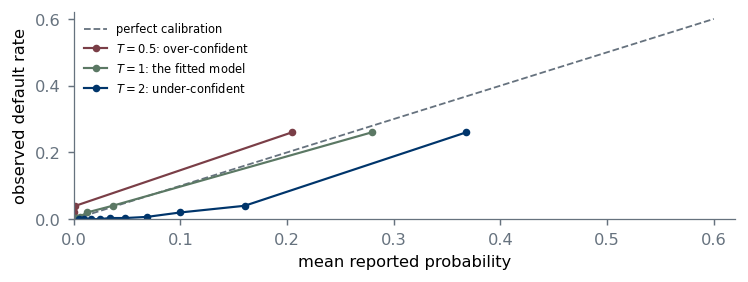

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/08-logistic-classification/calibration-temperature.pdf')

In [26]:
print(f"Default rows: {len(default)}")
print(f"Train/test: {len(train)}/{len(test)}; test defaults: {y_test.sum()}")
print(f"Logistic coefficients (intercept, balance, income): {w_hat}")
print(f"Held-out ROC AUC: {roc_auc_score(y_test, p_test):.6f}")


def calibration_temperature():
    """Same ranking, same decisions, different honesty.

    Dividing the logits by T>0 cannot change the ordering, so AUC and accuracy
    are identical to every decimal place; only the reported probabilities move.
    That is the cleanest demonstration that accuracy and AUC cannot detect
    miscalibration.
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import roc_auc_score, accuracy_score

    frame = pd.read_csv('Default.csv')
    yv = (frame["default"] == "Yes").to_numpy(int)
    Xv = frame[["balance", "income"]].to_numpy(float)
    Xtr, Xte, ytr, yte = train_test_split(Xv, yv, test_size=.3, random_state=26509, stratify=yv)
    scaler = StandardScaler().fit(Xtr)
    model = LogisticRegression().fit(scaler.transform(Xtr), ytr)
    z = model.decision_function(scaler.transform(Xte))

    def reliability(prob, bins=10):
        edges = np.quantile(prob, np.linspace(0, 1, bins+1)); edges[0] -= 1e-9
        xs, ys, ws = [], [], []
        for lo, hi in zip(edges[:-1], edges[1:]):
            m = (prob > lo) & (prob <= hi)
            if m.sum():
                xs.append(prob[m].mean()); ys.append(yte[m].mean()); ws.append(m.mean())
        return np.array(xs), np.array(ys), np.array(ws)

    settings = [(0.5, RED, "$T=0.5$: over-confident"),
                (1.0, GREEN, "$T=1$: the fitted model"),
                (2.0, BLUE, "$T=2$: under-confident")]
    fig, ax = plt.subplots(figsize=(FULL[0], 2.05))
    ax.plot([0, .6], [0, .6], ls="--", color=MUTED, lw=1, label="perfect calibration")
    rows = []
    for T, colour, label in settings:
        prob = 1/(1+np.exp(-z/T))
        xs, ys, ws = reliability(prob)
        ax.plot(xs, ys, "o-", color=colour, ms=3.2, lw=1.2, label=label)
        rows.append((T, roc_auc_score(yte, prob), accuracy_score(yte, prob > .5),
                     float(np.sum(ws*np.abs(xs-ys)))))
    ax.set(xlabel="mean reported probability", ylabel="observed default rate",
           xlim=(0, .62), ylim=(0, .62))
    ax.legend(fontsize=6.4, framealpha=0, loc="upper left")
    fig.tight_layout(pad=0.3)
    for T, auc, acc, e in rows:
        print(f"  T={T}: AUC={auc:.6f}  accuracy={acc:.4f}  calibration error={e:.4f}")
    return save(fig, OUT / "calibration-temperature.pdf",
                OUT / "calibration-temperature.svg")

calibration_temperature()